corrplot 0.95 loaded



      Age           Anxiety         Depression     Hours.per.day   
 Min.   :10.00   Min.   : 0.000   Min.   : 0.000   Min.   : 0.000  
 1st Qu.:18.00   1st Qu.: 4.000   1st Qu.: 2.000   1st Qu.: 2.000  
 Median :21.00   Median : 6.000   Median : 5.000   Median : 3.000  
 Mean   :24.76   Mean   : 5.874   Mean   : 4.887   Mean   : 3.711  
 3rd Qu.:27.00   3rd Qu.: 8.000   3rd Qu.: 7.000   3rd Qu.: 5.000  
 Max.   :89.00   Max.   :10.000   Max.   :10.000   Max.   :24.000  

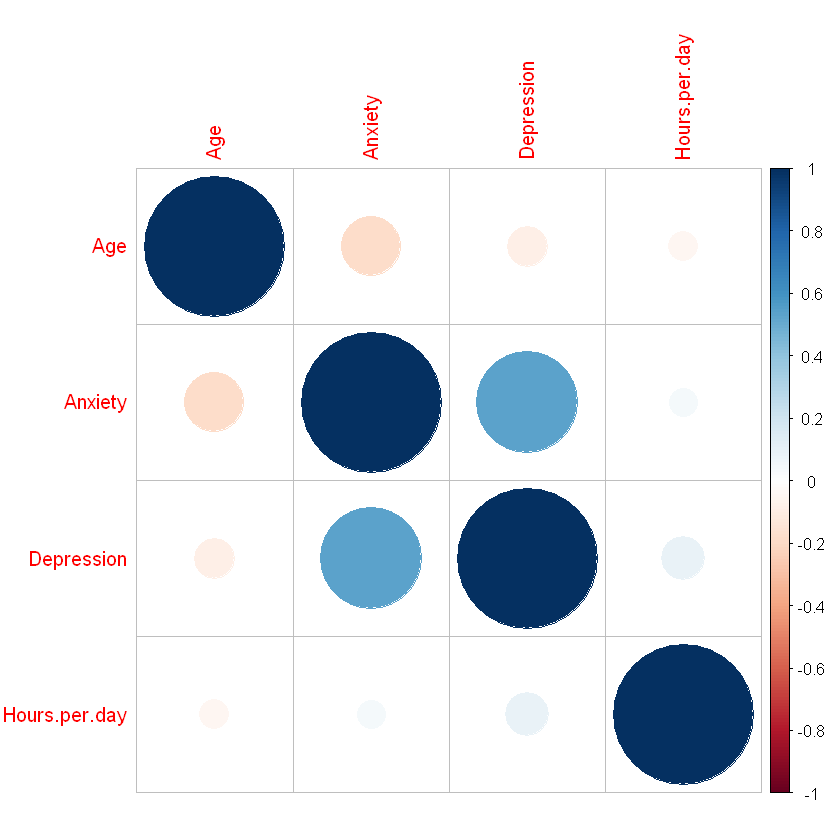

In [1]:
# Листинг 2 – EDA и корреляция в R
library(corrplot)
df <- read.csv("mxmh_survey_results.csv")
df <- na.omit(df)

# Описательная статистика
summary(df[, c("Age", "Anxiety", "Depression", "Hours.per.day")])

# Корреляционная матрица
corr_matrix <- cor(df[, c("Age", "Anxiety", "Depression", "Hours.per.day")])
corrplot(corr_matrix, method="circle")

In [2]:
# Листинг 4 – Линейная регрессия в R
model <- lm(Anxiety ~ Depression + Hours.per.day + Age, data=df)
summary(model)


Call:
lm(formula = Anxiety ~ Depression + Hours.per.day + Age, data = df)

Residuals:
    Min      1Q  Median      3Q     Max 
-7.7547 -1.4956  0.1875  1.4624  6.1696 

Coefficients:
               Estimate Std. Error t value Pr(>|t|)    
(Intercept)    4.379012   0.293613  14.914  < 2e-16 ***
Depression     0.478968   0.031064  15.419  < 2e-16 ***
Hours.per.day -0.012752   0.030160  -0.423    0.673    
Age           -0.032270   0.007959  -4.055 5.65e-05 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 2.32 on 625 degrees of freedom
Multiple R-squared:    0.3,	Adjusted R-squared:  0.2966 
F-statistic: 89.28 on 3 and 625 DF,  p-value: < 2.2e-16


In [3]:
# Листинг 6 – Логистическая регрессия в R
library(caret)
library(nnet)
# Удаление столбца Timestamp
if ("Timestamp" %in% colnames(df)) {
  df$Timestamp <- NULL
}

# Кодирование категориальных признаков
cat_columns <- names(df)[sapply(df, is.character)]
for (col in cat_columns) {
  # Преобразуем в фактор с сохранением порядка уровней
  df[[col]] <- factor(df[[col]])
  # Кодируем в числовой формат
  df[[col]] <- as.numeric(df[[col]])
}

# Заполнение пропусков в числовых столбцах
numeric_columns <- names(df)[sapply(df, is.numeric)]
for (col in numeric_columns) {
  df[[col]][is.na(df[[col]])] <- mean(df[[col]], na.rm = TRUE)
}

# Преобразуем целевую переменную в фактор
df$Music.effects <- as.factor(df$Music.effects)

# Подготовка данных для классификации
X_class <- df[, !names(df) %in% c("Music.effects", "Anxiety", "Depression")]
y_class <- df$Music.effects
temp_class <- cbind(X_class, Music.effects = y_class)
set.seed(42)
trainIndex_class <- createDataPartition(temp_class$Music.effects, p = 0.7, list = FALSE)
train_class <- temp_class[trainIndex_class, ]
test_class <- temp_class[-trainIndex_class, ]
model <- multinom(Music.effects ~ ., data = train_class)


# Прогнозирование на тестовых данных
pred_class <- predict(model, newdata = test_class)

# Преобразуем предсказания и тестовые данные в факторы с одинаковыми уровнями
levels_test <- levels(test_class$Music.effects)
pred_class <- factor(pred_class, levels = levels_test)
actual_class <- factor(test_class$Music.effects, levels = levels_test)

conf_matrix <- confusionMatrix(pred_class, actual_class)
print(conf_matrix)

Загрузка требуемого пакета: ggplot2

Загрузка требуемого пакета: lattice



# weights:  124 (90 variable)
initial  value 612.742108 
iter  10 value 610.908231
iter  20 value 608.529722
iter  30 value 604.938124
iter  40 value 598.614645
iter  50 value 594.856931
iter  60 value 589.928399
iter  70 value 578.346700
iter  80 value 569.341923
iter  90 value 563.681111
iter 100 value 560.919586
final  value 560.919586 
stopped after 100 iterations
Confusion Matrix and Statistics

          Reference
Prediction   1   2   3   4
         1   0   0   0   0
         2   1 138  38   3
         3   0   3   3   1
         4   0   0   0   0

Overall Statistics
                                          
               Accuracy : 0.754           
                 95% CI : (0.6859, 0.8139)
    No Information Rate : 0.754           
    P-Value [Acc > NIR] : 0.5395          
                                          
                  Kappa : 0.0753          
                                          
 Mcnemar's Test P-Value : NA              

Statistics by Class:

           

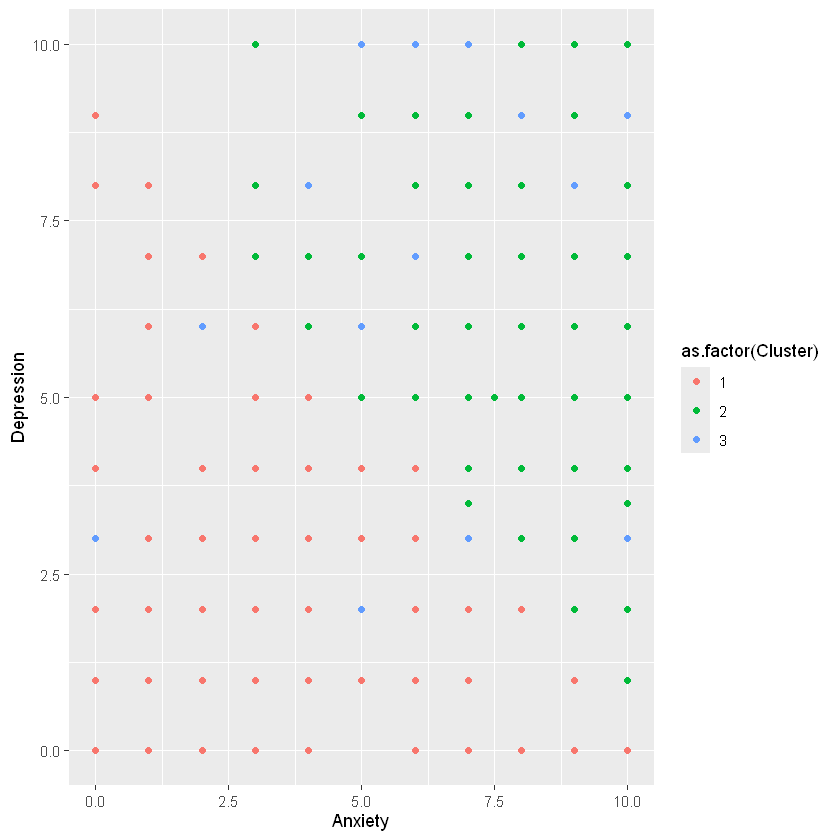

In [4]:
# Листинг 8 – K-means кластеризация в R
set.seed(42)
kmeans_result <- kmeans(df[, c("Anxiety", "Depression", "Hours.per.day")], centers=3)
df$Cluster <- kmeans_result$cluster

# Визуализация
library(ggplot2)
ggplot(df, aes(Anxiety, Depression, color=as.factor(Cluster))) + geom_point()

---
title: "Анализ музыкальных предпочтений"
output: pdf_document
---

```{r setup, include=FALSE}
knitr::opts_chunk$set(
  echo = TRUE,
  message = FALSE,
  warning = FALSE
)
# Подключение необходимых библиотек
library(ggplot2)
library(corrplot)
library(caret)
library(nnet)
```

## Загрузка и предобработка данных

```{r load-preprocess}
# Чтение данных и удаление пропусков
df <- read.csv("mxmh_survey_results.csv")
df <- na.omit(df)

# Удаление временной метки, если есть
if ("Timestamp" %in% names(df)) {
  df$Timestamp <- NULL
}

# Кодирование категориальных признаков
df[] <- lapply(df, function(x) {
  if (is.character(x)) as.numeric(factor(x)) else x
})

# Приведение целевой переменной к фактору с правильным порядком уровней
# (эффект музыки на самочувствие)
factor_levels <- c("No effect", "Improve", "Worsen")
df$Music.effects <- factor(df$Music.effects,
                             levels = factor_levels,
                             labels = factor_levels)
```

## Корреляционный анализ

```{r correlation-plot, fig.width=6, fig.height=6}
# Матрица корреляций для ключевых переменных
numeric_vars <- c("Age", "Anxiety", "Depression", "Hours.per.day")
corr_matrix <- cor(df[, numeric_vars])

# Визуализация корреляций
corrplot(corr_matrix, method = "circle", type = "upper",
         addCoef.col = "black", tl.col = "black", tl.cex = 0.8)
```

## Линейная регрессия

```{r linear-model-summary}
# Построение модели линейной регрессии
model_lm <- lm(Anxiety ~ Depression + Hours.per.day + Age, data = df)

# Вывод результатов модели
summary(model_lm)
```

## Многоклассовая логистическая регрессия

```{r logistic-regression}
# Разделение на обучающую и тестовую выборки
set.seed(123)
trainIndex <- createDataPartition(df$Music.effects, p = 0.7, list = FALSE)
train_data <- df[trainIndex, ]
test_data  <- df[-trainIndex, ]

# Обучение модели многоклассовой логистической регрессии
model_multinom <- multinom(Music.effects ~ ., data = train_data)

# Предсказания на тестовой выборке
predictions <- predict(model_multinom, newdata = test_data)

# Оценка качества модели
confusionMatrix(predictions, test_data$Music.effects)
```

## Кластерный анализ

```{r clustering, fig.width=6, fig.height=5}
# Кластеризация методом k-means
set.seed(123)
kmeans_result <- kmeans(df[, c("Anxiety", "Depression", "Hours.per.day")], centers = 3)
df$Cluster <- factor(kmeans_result$cluster)

# Визуализация кластеров
ggplot(df, aes(x = Anxiety, y = Depression, color = Cluster)) +
  geom_point(alpha = 0.6, size = 2) +
  theme_minimal() +
  labs(title = "Кластеры по тревожности и депрессии",
       x = "Уровень тревожности",
       y = "Уровень депрессии")
```

```{r save-model, include=FALSE}
# Сохранение обученной модели многоклассовой регрессии
saveRDS(model_multinom, "music_effects_model.rds")


In [4]:
rmarkdown::render("C:/Users/borga/Desktop/Stud/ЯПСОД/Ноутбуки/Япсод12_R.Rmd")




processing file: Япсод12_R.Rmd



1/14                       
2/14 [setup]               
3/14                       
4/14 [load-preprocess]     
5/14                       
6/14 [correlation-plot]    
7/14                       
8/14 [linear-model-summary]
9/14                       
10/14 [logistic-regression] 
11/14                       
12/14 [clustering]          
13/14                       
14/14 [save-model]          


output file: Япсод12_R.knit.md




"C:/PROGRA~1/Pandoc/pandoc" +RTS -K512m -RTS Япсод12_R.knit.md --to latex --from markdown+autolink_bare_uris+tex_math_single_backslash --output Япсод12_R.tex --lua-filter "C:\Users\borga\AppData\Local\R\win-library\4.4\rmarkdown\rmarkdown\lua\pagebreak.lua" --lua-filter "C:\Users\borga\AppData\Local\R\win-library\4.4\rmarkdown\rmarkdown\lua\latex-div.lua" --embed-resources --standalone --table-of-contents --toc-depth 2 --number-sections --highlight-style tango --pdf-engine xelatex --variable graphics --variable "geometry:margin=1in" 



Output created: Япсод12_R.pdf

